In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [21]:
file_path = 'data_var.csv'
data = pd.read_csv(file_path)
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data.set_index('Date', inplace=True)

In [23]:
def test_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic {series.name}: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1] < 0.05

for col in data.columns:
    stationary = test_stationarity(data[col])
    if not stationary:
        print(f'La série {col} semble non stationnaire, différencier.')

ADF Statistic GAP: -4.2887278252054
p-value: 0.0004646073028628616
ADF Statistic INF: -2.0799432524039188
p-value: 0.2526556175722676
La série INF semble non stationnaire, différencier.
ADF Statistic IR3M: -2.0482349620940026
p-value: 0.26583211153714326
La série IR3M semble non stationnaire, différencier.


In [24]:
data_diff = data.diff().dropna()

In [25]:
model = VAR(data_diff)
lag_order = model.select_order(maxlags=8)
print(lag_order.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -4.194      -4.126     0.01508      -4.166
1      -4.512     -4.237*     0.01098     -4.400*
2      -4.548      -4.068     0.01059      -4.353
3      -4.536      -3.850     0.01073      -4.257
4      -4.690      -3.798    0.009211      -4.328
5      -4.639      -3.542    0.009710      -4.193
6      -4.659      -3.356    0.009547      -4.130
7      -4.653      -3.144    0.009649      -4.040
8     -4.729*      -3.014   0.008988*      -4.033
-------------------------------------------------


C:\Users\llall\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [26]:
optimal_lag = lag_order.selected_orders['aic']

In [27]:
var_model = model.fit(optimal_lag)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 19, Nov, 2025
Time:                     14:54:09
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -3.01438
Nobs:                     123.000    HQIC:                  -4.03260
Log likelihood:          -157.747    FPE:                 0.00898761
AIC:                     -4.72913    Det(Omega_mle):      0.00515911
--------------------------------------------------------------------
Results for equation GAP
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.037166         0.058621            0.634           0.526
L1.GAP          0.144014         0.101594            1.418           0.156
L1.INF          0.193505         0.194952            0.993           0.321
L1.IR3M    

In [28]:
forecast_steps = 12
forecast_diff = var_model.forecast(data_diff.values[-optimal_lag:], steps=forecast_steps)

In [29]:
last_original = data.iloc[-1].values
forecast = np.vstack([last_original, forecast_diff]).cumsum(axis=0)[1:]

In [31]:
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_steps+1, freq='QE')[1:]
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=data.columns)

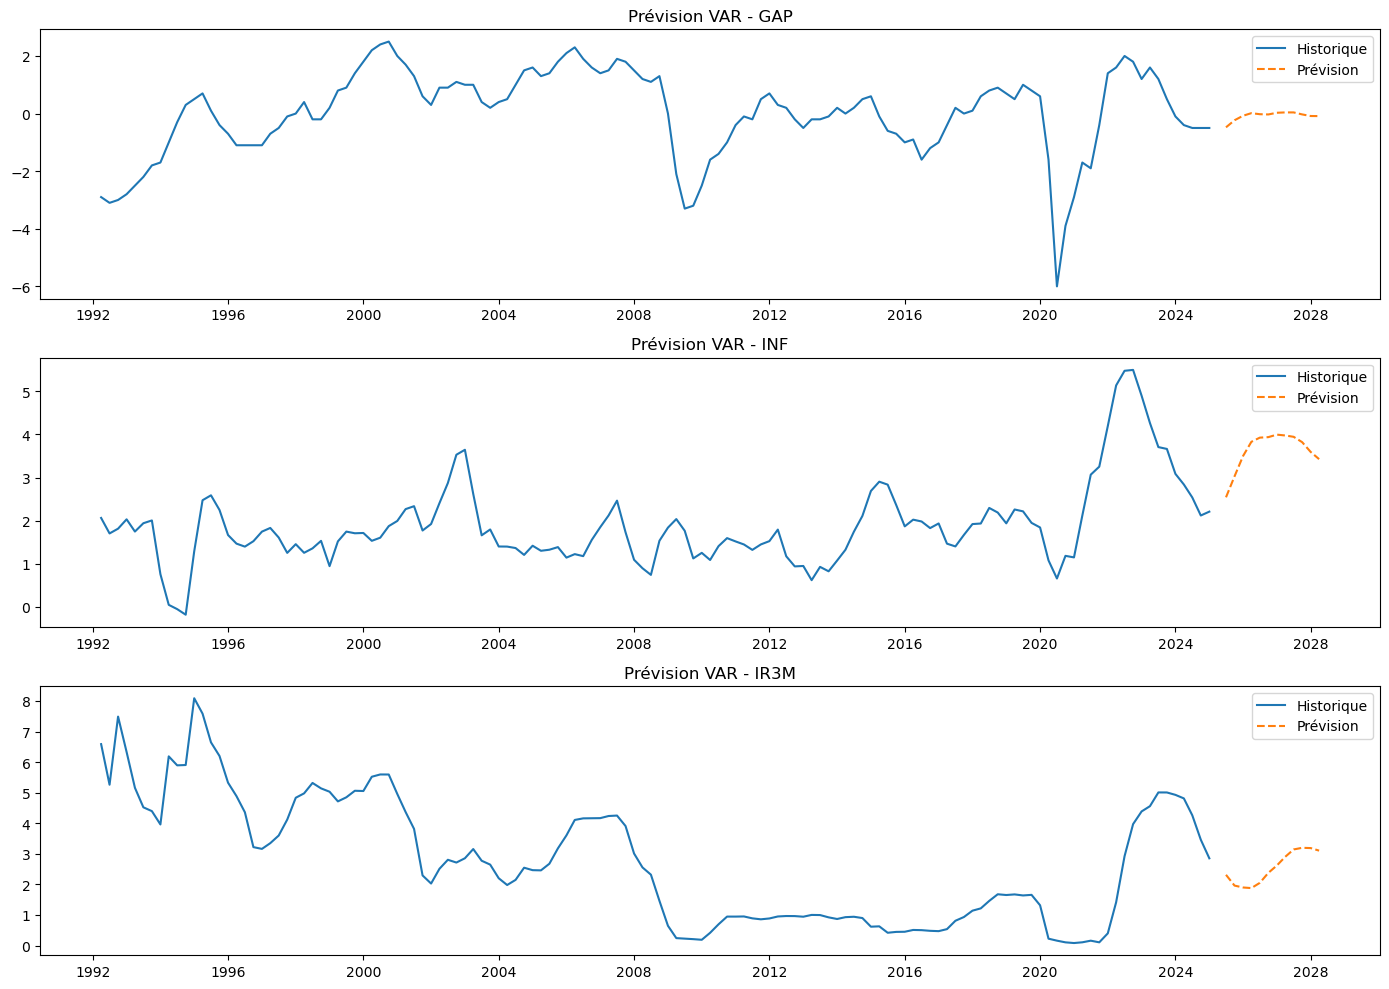

In [32]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(data.columns):
    plt.subplot(len(data.columns), 1, i+1)
    plt.plot(data.index, data[col], label='Historique')
    plt.plot(forecast_df.index, forecast_df[col], label='Prévision', linestyle='--')
    plt.title(f'Prévision VAR - {col}')
    plt.legend()
plt.tight_layout()
plt.show()

In [33]:
print("\nPrévisions VAR pour les 12 prochains trimestres :")
print(forecast_df.round(3))


Prévisions VAR pour les 12 prochains trimestres :
              GAP    INF   IR3M
2025-06-30 -0.477  2.541  2.314
2025-09-30 -0.233  3.027  1.962
2025-12-31 -0.075  3.499  1.899
2026-03-31  0.014  3.830  1.880
2026-06-30 -0.022  3.926  2.051
2026-09-30 -0.030  3.938  2.378
2026-12-31  0.028  3.996  2.618
2027-03-31  0.040  3.976  2.902
2027-06-30  0.040  3.945  3.143
2027-09-30 -0.029  3.821  3.197
2027-12-31 -0.085  3.594  3.189
2028-03-31 -0.088  3.427  3.105


In [39]:
stderr = np.sqrt(np.diag(var_model.sigma_u))

In [40]:
shock = np.zeros(len(data.columns))
gap_index = list(data.columns).index('GAP')
shock[gap_index] = stderr[gap_index]

In [41]:
irf = var_model.irf(12)

In [42]:
irf_response = irf.irfs[:, 0, :] * shock[0]

In [43]:
forecast_shock = forecast + irf_response[1:]

In [44]:
forecast_shock_df = pd.DataFrame(forecast_shock, index=forecast_index, columns=data.columns)

In [45]:
print("Prévisions sans choc (12 trimestres) :")
print(forecast_df.round(3))
print("\nPrévisions avec choc IRF (1 écart-type GAP au dernier trimestre) :")
print(forecast_shock_df.round(3))

Prévisions sans choc (12 trimestres) :
              GAP    INF   IR3M
2025-06-30 -0.477  2.541  2.314
2025-09-30 -0.233  3.027  1.962
2025-12-31 -0.075  3.499  1.899
2026-03-31  0.014  3.830  1.880
2026-06-30 -0.022  3.926  2.051
2026-09-30 -0.030  3.938  2.378
2026-12-31  0.028  3.996  2.618
2027-03-31  0.040  3.976  2.902
2027-06-30  0.040  3.945  3.143
2027-09-30 -0.029  3.821  3.197
2027-12-31 -0.085  3.594  3.189
2028-03-31 -0.088  3.427  3.105

Prévisions avec choc IRF (1 écart-type GAP au dernier trimestre) :
              GAP    INF   IR3M
2025-06-30 -0.385  2.665  2.724
2025-09-30 -0.290  3.093  2.079
2025-12-31 -0.180  3.449  1.930
2026-03-31 -0.030  3.733  1.942
2026-06-30 -0.027  3.943  2.066
2026-09-30 -0.154  4.002  2.389
2026-12-31 -0.073  4.053  2.483
2027-03-31 -0.054  3.909  2.809
2027-06-30  0.033  3.866  3.067
2027-09-30  0.021  3.784  3.129
2027-12-31 -0.035  3.591  3.156
2028-03-31 -0.052  3.503  3.102


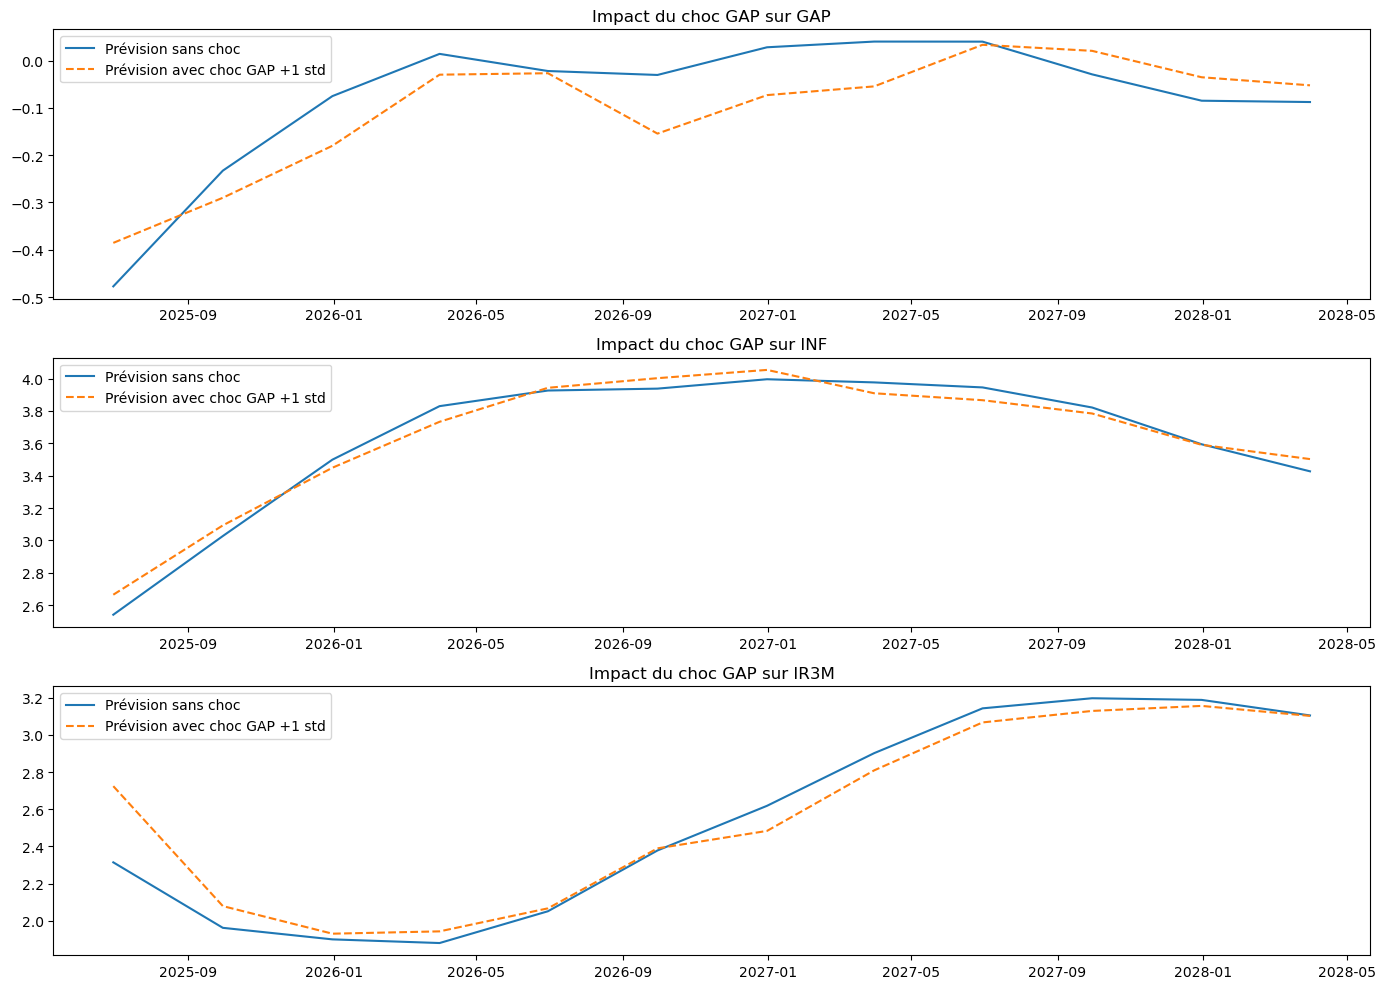

In [46]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(data.columns):
    plt.subplot(len(data.columns), 1, i+1)
    plt.plot(forecast_df.index, forecast_df[col], label='Prévision sans choc')
    plt.plot(forecast_shock_df.index, forecast_shock_df[col], label='Prévision avec choc GAP +1 std', linestyle='--')
    plt.title(f'Impact du choc GAP sur {col}')
    plt.legend()
plt.tight_layout()
plt.show()

In [47]:
stderr = np.sqrt(np.diag(var_model.sigma_u))

In [48]:
shock = np.zeros(len(data.columns))

In [49]:
inf_index = list(data.columns).index('INF')

In [50]:
shock[inf_index] = stderr[inf_index]

In [51]:
irf = var_model.irf(12)

In [52]:
irf_response = irf.irfs[:, inf_index, :] * shock[inf_index]

In [53]:
forecast_shock = forecast + irf_response[1:] 

In [54]:
forecast_shock_df = pd.DataFrame(forecast_shock, index=forecast_index, columns=data.columns)

In [55]:
print("Prévisions sans choc (12 trimestres) :")
print(forecast_df.round(3))
print("\nPrévisions avec choc IRF +1 écart-type sur INF (12 trimestres) :")
print(forecast_shock_df.round(3))

Prévisions sans choc (12 trimestres) :
              GAP    INF   IR3M
2025-06-30 -0.477  2.541  2.314
2025-09-30 -0.233  3.027  1.962
2025-12-31 -0.075  3.499  1.899
2026-03-31  0.014  3.830  1.880
2026-06-30 -0.022  3.926  2.051
2026-09-30 -0.030  3.938  2.378
2026-12-31  0.028  3.996  2.618
2027-03-31  0.040  3.976  2.902
2027-06-30  0.040  3.945  3.143
2027-09-30 -0.029  3.821  3.197
2027-12-31 -0.085  3.594  3.189
2028-03-31 -0.088  3.427  3.105

Prévisions avec choc IRF +1 écart-type sur INF (12 trimestres) :
              GAP    INF   IR3M
2025-06-30 -0.467  2.654  2.326
2025-09-30 -0.188  3.072  1.917
2025-12-31 -0.068  3.523  1.898
2026-03-31  0.004  3.650  1.883
2026-06-30 -0.017  3.859  2.036
2026-09-30 -0.052  3.931  2.393
2026-12-31  0.001  4.005  2.600
2027-03-31  0.021  3.990  2.868
2027-06-30  0.018  3.916  3.127
2027-09-30 -0.031  3.766  3.186
2027-12-31 -0.073  3.551  3.194
2028-03-31 -0.076  3.459  3.124


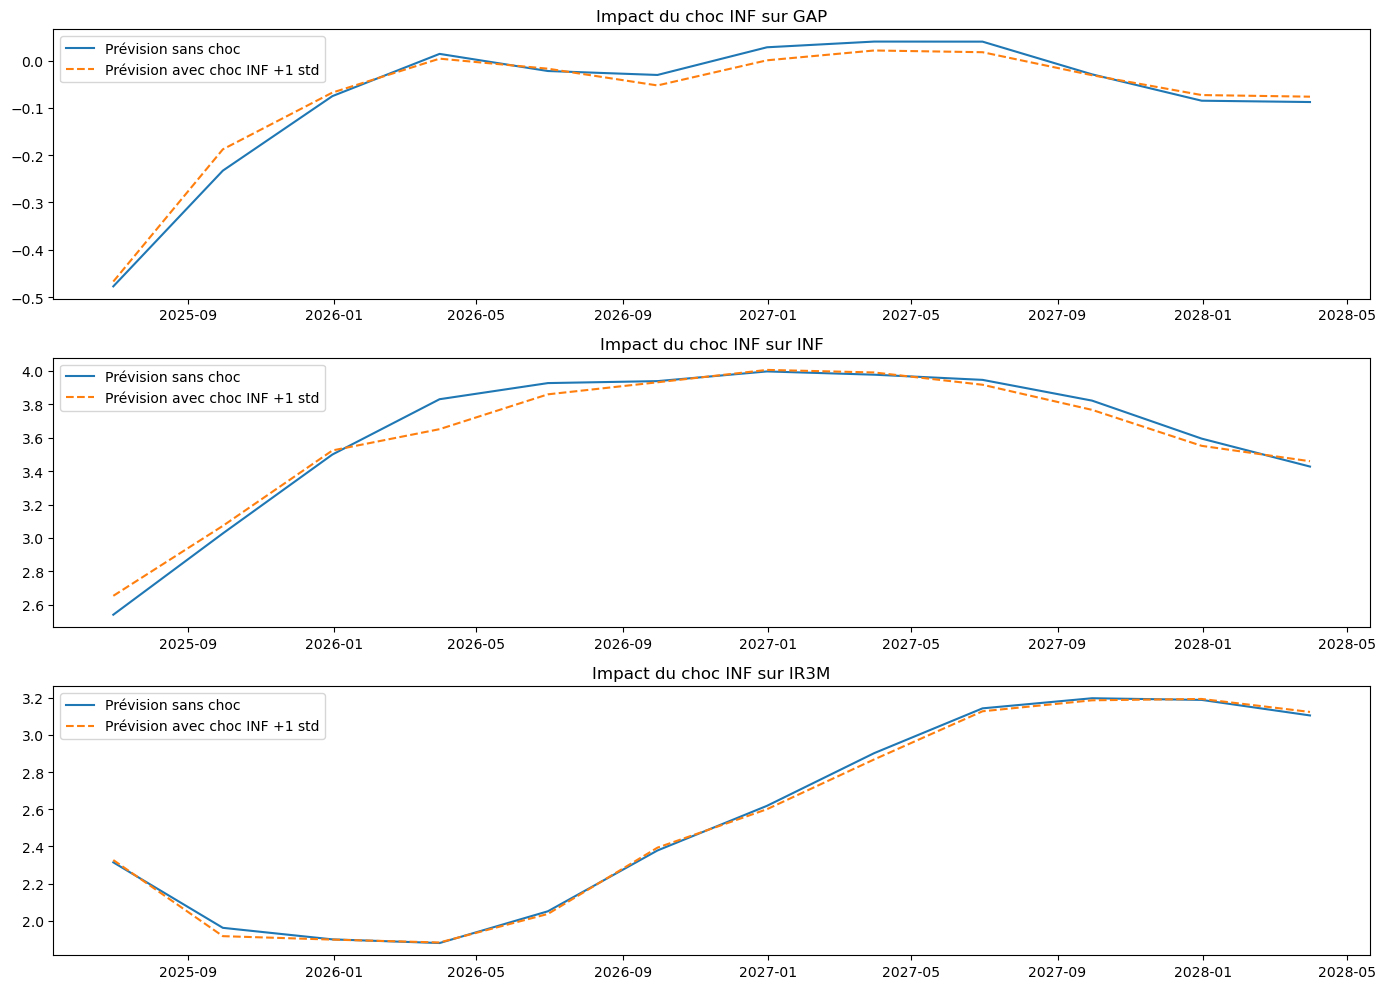

In [56]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(data.columns):
    plt.subplot(len(data.columns), 1, i+1)
    plt.plot(forecast_df.index, forecast_df[col], label='Prévision sans choc')
    plt.plot(forecast_shock_df.index, forecast_shock_df[col], label='Prévision avec choc INF +1 std', linestyle='--')
    plt.title(f'Impact du choc INF sur {col}')
    plt.legend()
plt.tight_layout()
plt.show()

In [57]:
stderr = np.sqrt(np.diag(var_model.sigma_u))

In [58]:
shock = np.zeros(len(data.columns))

In [59]:
ir3m_index = list(data.columns).index('IR3M')

In [60]:
shock[ir3m_index] = stderr[ir3m_index]

In [61]:
irf = var_model.irf(12)

In [62]:
irf_response = irf.irfs[:, ir3m_index, :] * shock[ir3m_index]

In [63]:
forecast_shock = forecast + irf_response[1:]

In [64]:
forecast_shock_df = pd.DataFrame(forecast_shock, index=forecast_index, columns=data.columns)

In [65]:
print("Prévisions sans choc (12 trimestres) :")
print(forecast_df.round(3))
print("\nPrévisions avec choc IRF +1 écart-type sur IR3M (12 trimestres) :")
print(forecast_shock_df.round(3))

Prévisions sans choc (12 trimestres) :
              GAP    INF   IR3M
2025-06-30 -0.477  2.541  2.314
2025-09-30 -0.233  3.027  1.962
2025-12-31 -0.075  3.499  1.899
2026-03-31  0.014  3.830  1.880
2026-06-30 -0.022  3.926  2.051
2026-09-30 -0.030  3.938  2.378
2026-12-31  0.028  3.996  2.618
2027-03-31  0.040  3.976  2.902
2027-06-30  0.040  3.945  3.143
2027-09-30 -0.029  3.821  3.197
2027-12-31 -0.085  3.594  3.189
2028-03-31 -0.088  3.427  3.105

Prévisions avec choc IRF +1 écart-type sur IR3M (12 trimestres) :
              GAP    INF   IR3M
2025-06-30 -0.448  2.553  2.453
2025-09-30 -0.224  3.058  1.967
2025-12-31 -0.055  3.485  2.012
2026-03-31  0.023  3.839  1.911
2026-06-30 -0.024  3.967  2.037
2026-09-30 -0.006  3.981  2.358
2026-12-31  0.034  4.022  2.520
2027-03-31 -0.014  4.015  2.852
2027-06-30  0.007  3.939  3.105
2027-09-30 -0.035  3.782  3.115
2027-12-31 -0.097  3.587  3.164
2028-03-31 -0.101  3.401  3.103


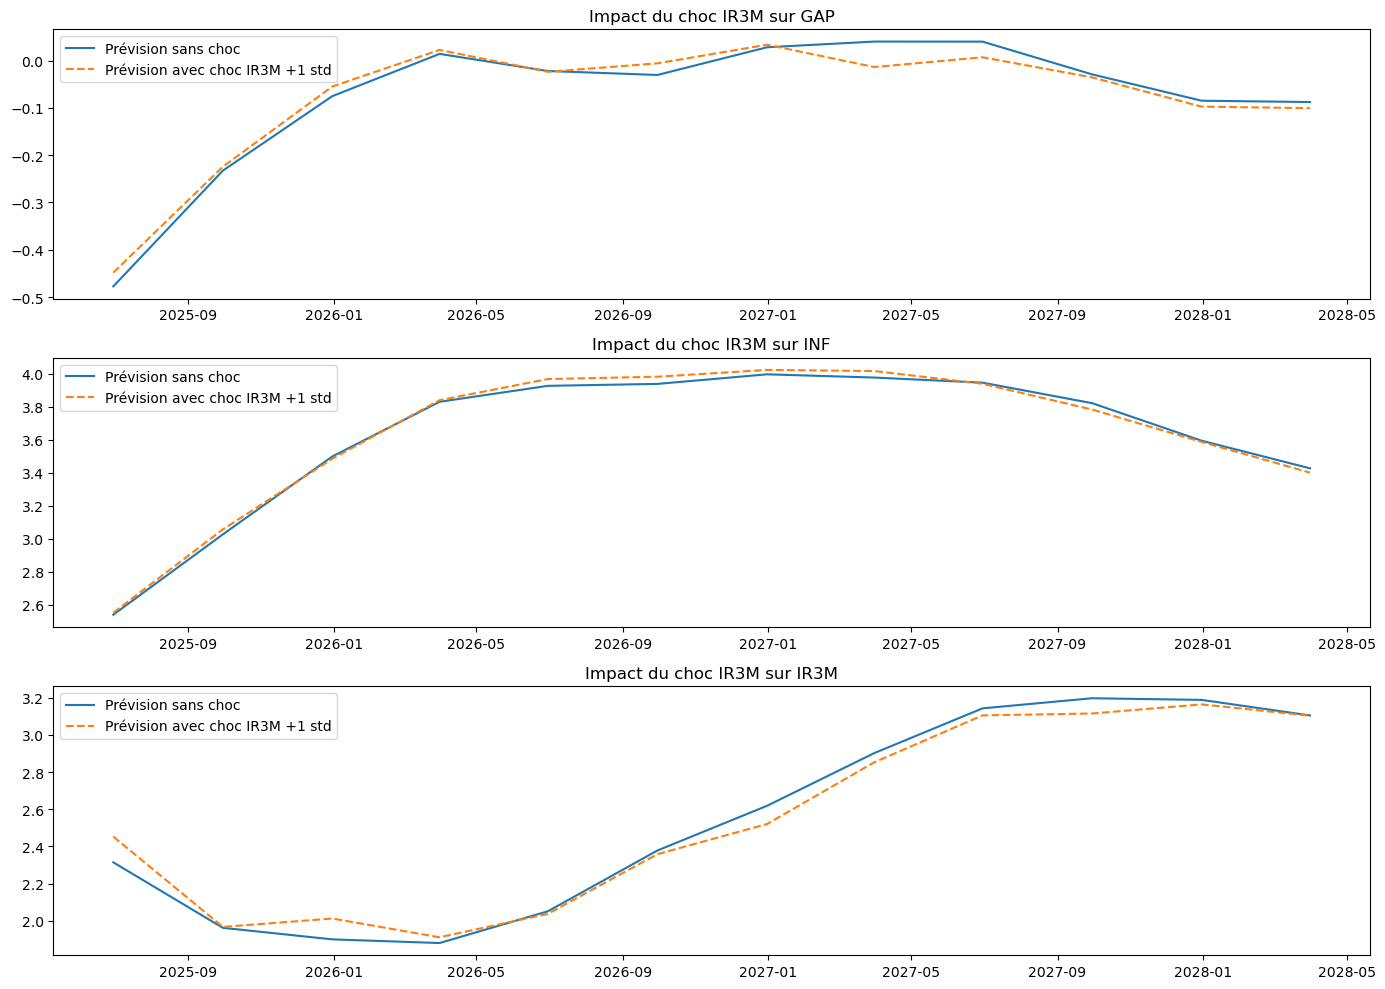

In [66]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(data.columns):
    plt.subplot(len(data.columns), 1, i+1)
    plt.plot(forecast_df.index, forecast_df[col], label='Prévision sans choc')
    plt.plot(forecast_shock_df.index, forecast_shock_df[col], label='Prévision avec choc IR3M +1 std', linestyle='--')
    plt.title(f'Impact du choc IR3M sur {col}')
    plt.legend()
plt.tight_layout()
plt.show()